# Business Case:

 Flight ticket prices can be something hard to guess, today we might see a price, check out the price of the same flight tomorrow, it will be a different story. We might have often heard travelers saying that flight ticket prices are so unpredictable

# Domain Analysis 
1.	Airline: So this column will have all the types of airlines like Indigo, Jet Airways, Air India, and many more.
2.	Date_of_Journey: This column will let us know about the date on which the passenger’s journey will start.
3.	Source: This column holds the name of the place from where the passenger’s journey will start.
4.	Destination: This column holds the name of the place to where passengers wanted to travel.
5.	Route: Here we can know about what the route is through which passengers have opted to travel from his/her source to their destination.
6.	Arrival_Time: Arrival time is when the passenger will reach his/her destination.
7.	Duration: Duration is the whole period that a flight will take to complete its journey from source to destination.
8.	Total_Stops: This will let us know in how many places flights will stop there for the flight in the whole journey.
9.	Additional_Info: In this column, we will get information about food, kind of food, and other amenities.
10.	Price: Price of the flight for a complete journey including all the expenses before onboarding.


In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
import pandas as pd
import numpy as np

In [7]:

df=pd.read_csv("Flight_Fare.csv")
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [8]:
# df.nunique()
df.nunique().sort_values(ascending=False)


Price              1870
Arrival_Time       1343
Duration            368
Dep_Time            222
Route               128
Date_of_Journey      44
Airline              12
Additional_Info      10
Destination           6
Source                5
Total_Stops           5
dtype: int64

In [9]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [10]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [11]:
df['Airline'].unique()



array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [12]:
df['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [13]:
df['Destination'].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [14]:
df.isnull().sum()



Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [15]:
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

### There were only two null values in the dataset, so instead of imputing, I dropped those rows to keep the data clean and avoid unnecessary assumptions.

In [18]:
df.drop_duplicates(inplace=True)


In [19]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648


# Exploratory Data Analysis (EDA)

In [21]:
import seaborn as  sns

In [22]:
import matplotlib.pyplot as plt


# Univariate Analysis

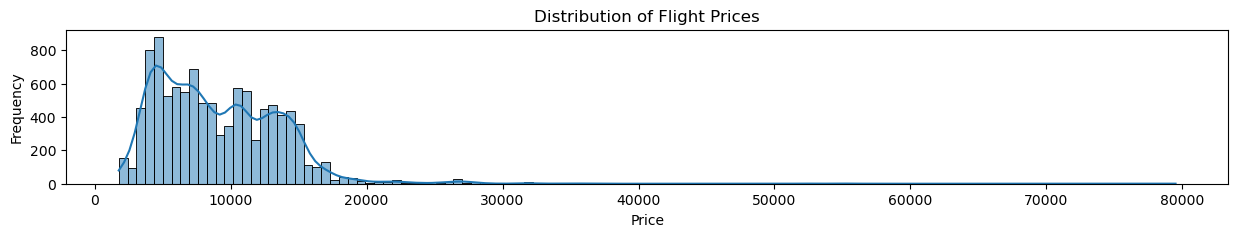

In [24]:
#Distribution of flight prices
plt.figure(figsize=(15,2))
sns.histplot(df.Price,kde='True')
plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

* Flight prices are right-skewed

* Few high-priced flights act as outliers

* Majority of prices lie in a moderate range

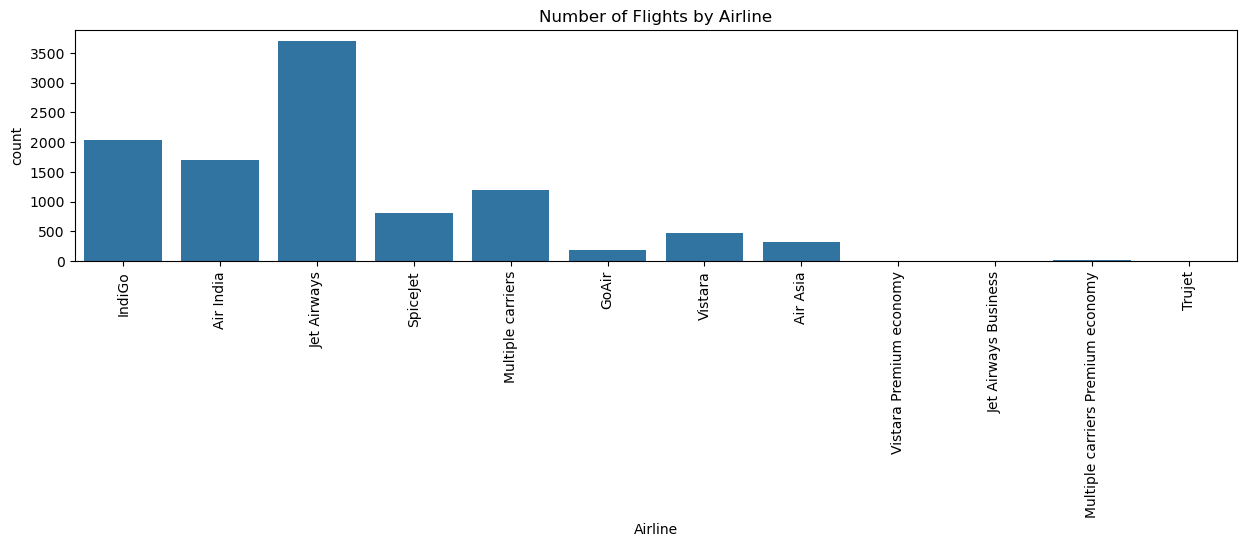

In [26]:
# Count of flights by airline
plt.figure(figsize=(15,3))
sns.countplot(x='Airline', data=df)
plt.xticks(rotation=90)
plt.title("Number of Flights by Airline")
plt.show()

* Certain airlines dominate the dataset

* Some airlines have very few observations

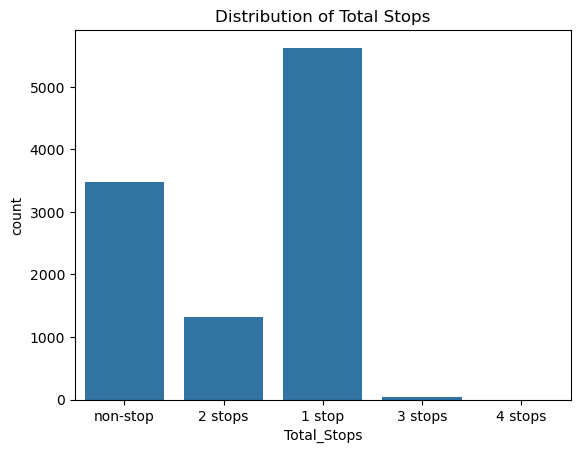

In [28]:
sns.countplot(x='Total_Stops', data=df)
plt.title("Distribution of Total Stops")
plt.show()


* Most flights have 1 stop or are non-stop

* Flights with 3 or more stops are rare

In [30]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format="%d/%m/%Y")

df['Journey_Day'] = df['Date_of_Journey'].dt.day
df['Journey_Month']=df['Date_of_Journey'].dt.strftime('%B')
df['Journey_Weekday'] = df['Date_of_Journey'].dt.day_name()


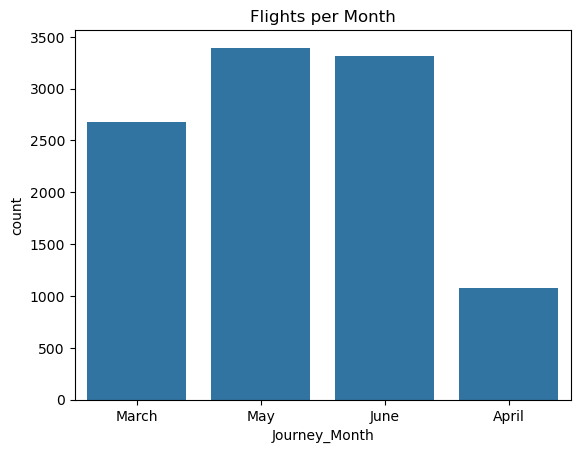

In [31]:
sns.countplot(x='Journey_Month', data=df)
plt.title("Flights per Month")
plt.show()

* Number of flights varies across months

* Indicates seasonality in travel demand

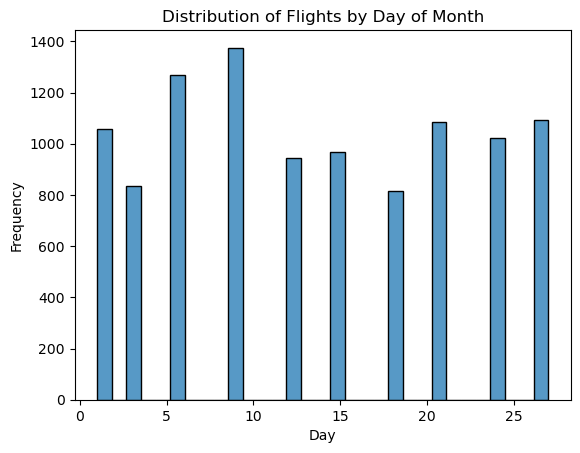

In [33]:
sns.histplot(df['Journey_Day'], bins=31)
plt.title("Distribution of Flights by Day of Month")
plt.xlabel("Day")
plt.ylabel("Frequency")
plt.show()


* Flights are spread across most days

* Slight variation toward mid-month dates

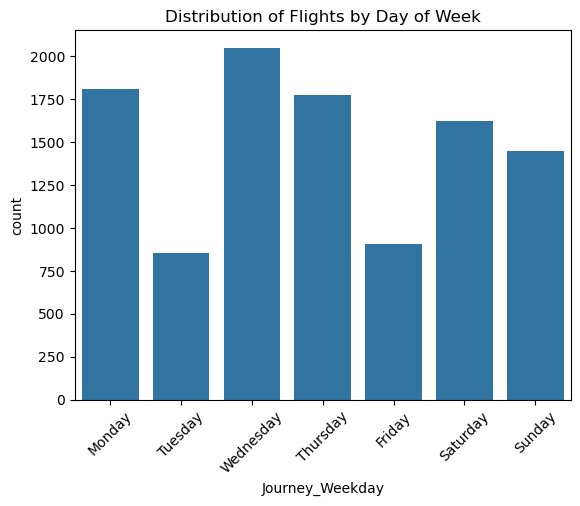

In [35]:
sns.countplot(
    x='Journey_Weekday',
    data=df,
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.title("Distribution of Flights by Day of Week")
plt.xticks(rotation=45)
plt.show()


* Weekday travel is more common than weekends

* Reflects business and regular travel behavior

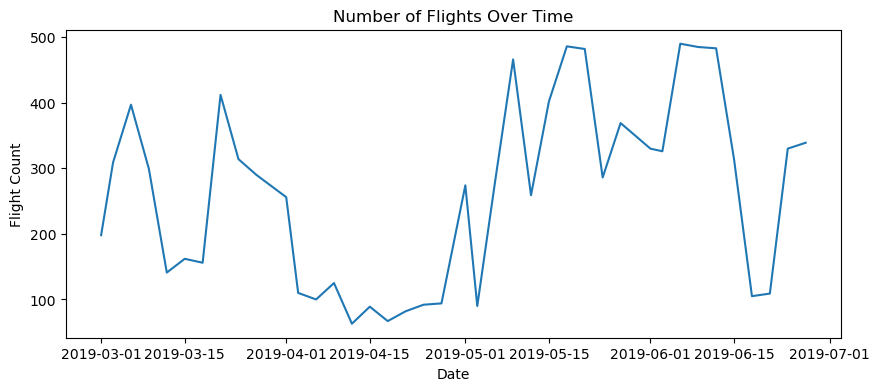

In [37]:
daily_flights = df.groupby('Date_of_Journey').size()

plt.figure(figsize=(10,4))
plt.plot(daily_flights)
plt.title("Number of Flights Over Time")
plt.xlabel("Date")
plt.ylabel("Flight Count")
plt.show()

* Fluctuations in flight frequency over time

* Confirms temporal patterns

# Bivariate Analysis

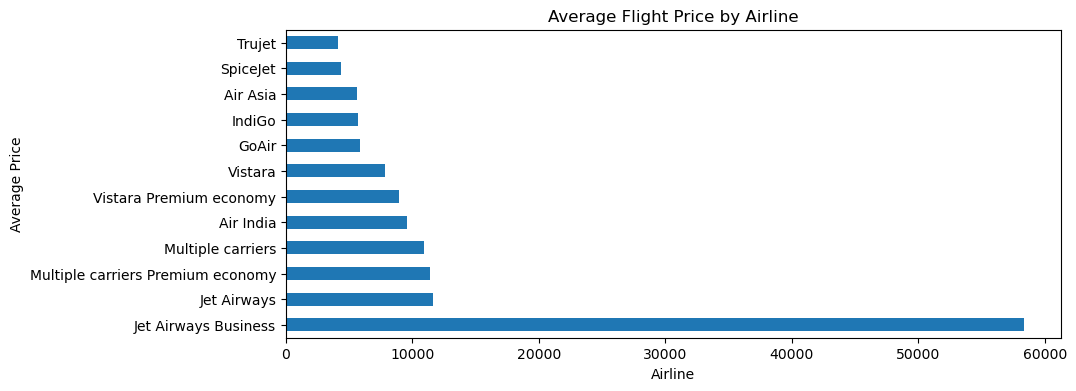

In [40]:
airline_price = df.groupby('Airline')['Price'].mean().sort_values(ascending=False)

airline_price.plot(kind='barh', figsize=(10,4))
plt.title("Average Flight Price by Airline")
plt.ylabel("Average Price")
plt.xlabel("Airline")
plt.show()


* Prices vary significantly across airlines

* Some airlines consistently have higher median prices

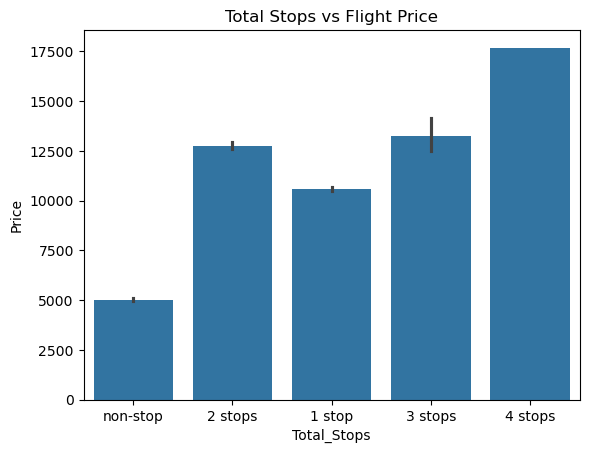

In [42]:
sns.barplot(x='Total_Stops', y='Price', data=df)
plt.title("Total Stops vs Flight Price")
plt.show()


* Non-stop flights have the highest median prices

* Ticket price decreases as the number of stops increases

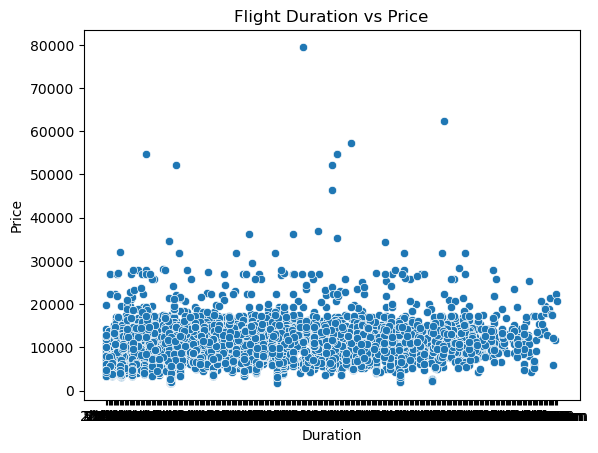

In [44]:
sns.scatterplot(x='Duration', y='Price', data=df)
plt.title("Flight Duration vs Price")
plt.show()

* Positive correlation between duration and price

* Some overlap exists due to airline pricing strategies

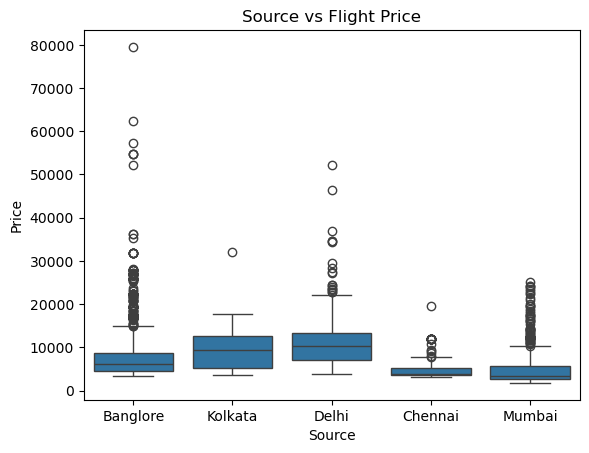

In [46]:
sns.boxplot(x='Source', y='Price', data=df)
plt.title("Source vs Flight Price")
plt.show()

* Price varies noticeably across source cities

* Certain cities have consistently higher fares

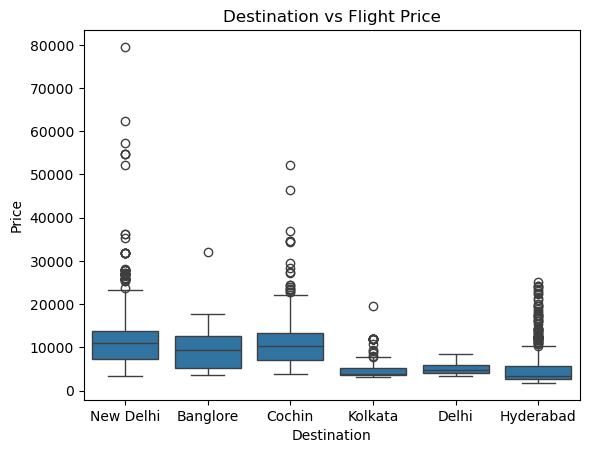

In [48]:
sns.boxplot(x='Destination', y='Price', data=df)
plt.title("Destination vs Flight Price")
plt.show()

* Certain destinations show higher median prices

* Price spread differs by destination

# Multivariate Analysis

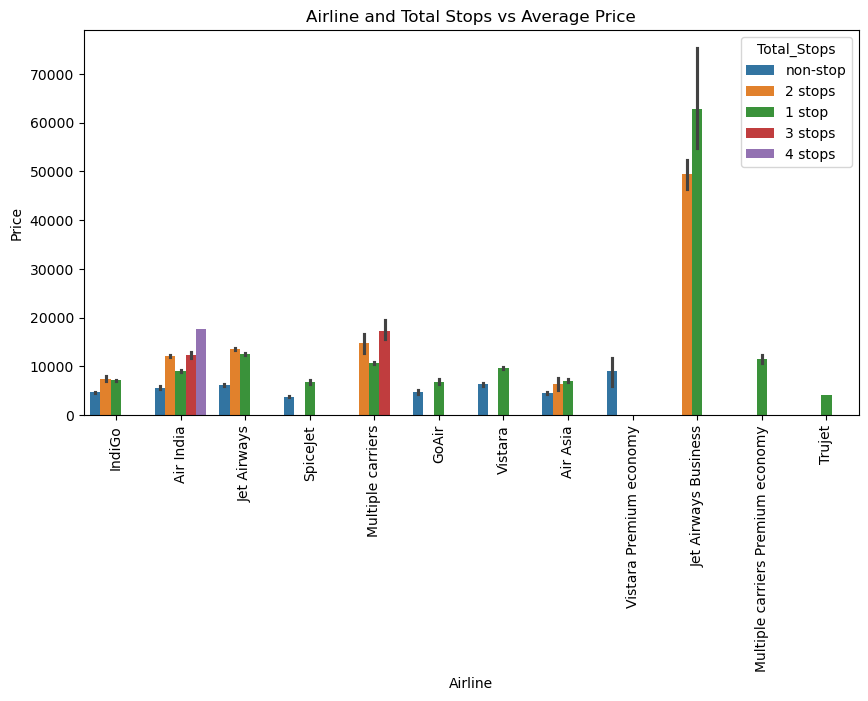

In [51]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='Airline',
    y='Price',
    hue='Total_Stops',
    data=df,
    estimator='mean'
)
plt.xticks(rotation=90)
plt.title("Airline and Total Stops vs Average Price")
plt.show()



* For the same airline, non-stop flights are always costlier

* Price variation differs across airlines

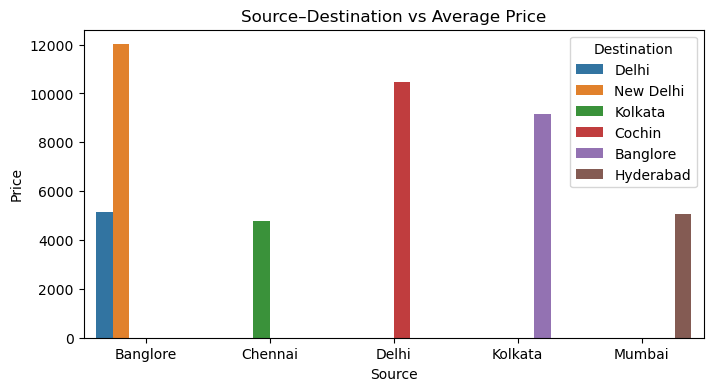

In [53]:
route_price = df.groupby(['Source', 'Destination'])['Price'].mean().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(x='Source', y='Price', hue='Destination', data=route_price)
plt.title("Source–Destination vs Average Price")
plt.show()


Certain routes consistently have higher prices

Route demand impacts pricing significantly

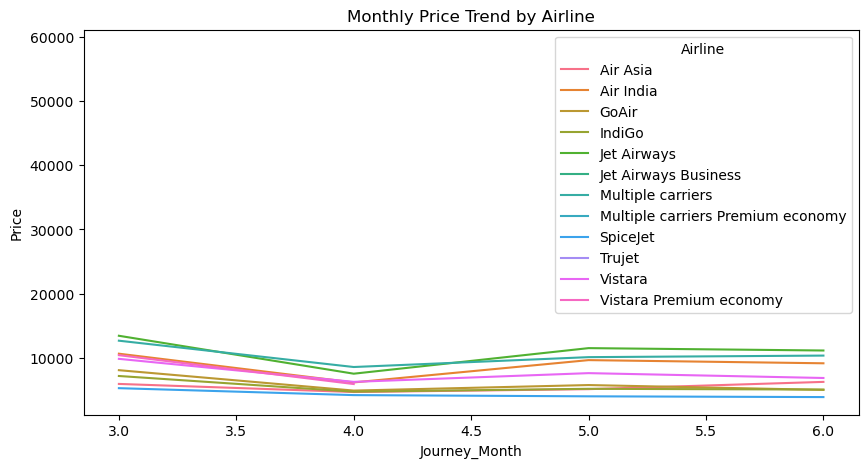

In [55]:
df['Journey_Month'] = pd.to_datetime(df['Date_of_Journey'], format="%d/%m/%Y").dt.month

month_airline_price = df.groupby(['Journey_Month', 'Airline'])['Price'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(
    x='Journey_Month',
    y='Price',
    hue='Airline',
    data=month_airline_price
)
plt.title("Monthly Price Trend by Airline")
plt.show()


Prices peak in certain months

Airlines respond differently to seasonal demand

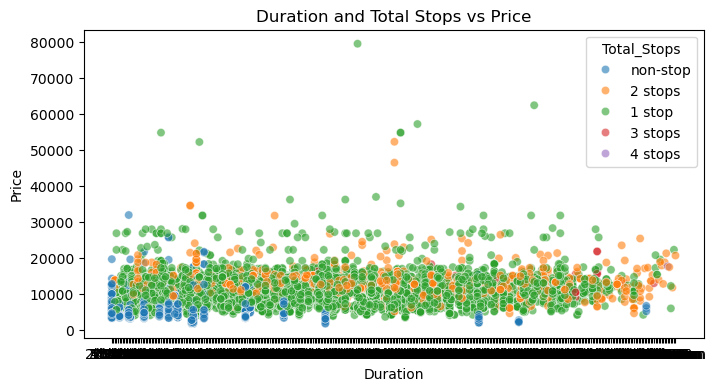

In [57]:
plt.figure(figsize=(8,4))
sns.scatterplot(
    x='Duration',
    y='Price',
    hue='Total_Stops',
    data=df,
    alpha=0.6
)
plt.title("Duration and Total Stops vs Price")
plt.show()


Longer non-stop flights are the most expensive

Multiple stops reduce price even with longer duration

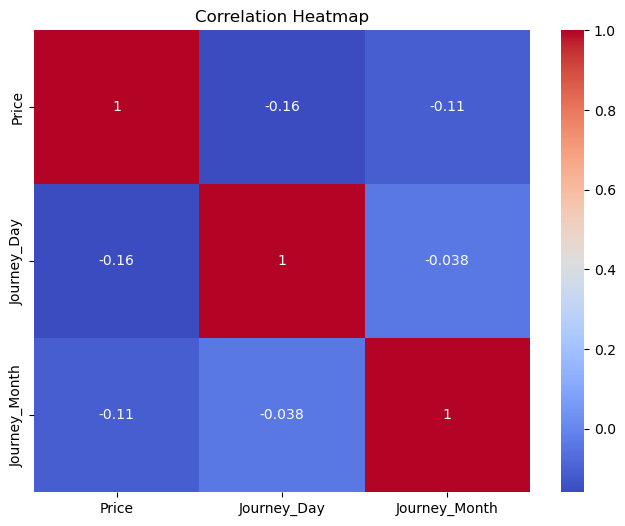

In [59]:
numeric_data = df.select_dtypes(include='number')
plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [60]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Weekday
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,Sunday
1,Air India,2019-05-01,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,Wednesday
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,Sunday
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,Sunday
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4,Tuesday
10679,Air India,2019-04-27,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4,Saturday
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229,27,4,Saturday
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3,Friday


In [61]:
def convert_duration(duration):
    hours = 0
    minutes = 0
    
    if 'h' in duration:
        hours = int(duration.split('h')[0])
    if 'm' in duration:
        minutes = int(duration.split('m')[0].split()[-1])
        
    return hours * 60 + minutes

df['Duration'] = df['Duration'].apply(convert_duration)



* The Duration feature was originally in string format (e.g., "2h 50m").
* A custom function was created to extract hours and minutes separately and convert the total duration into minutes.

In [63]:
# Departure time features
df['Dep_hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_min'] = pd.to_datetime(df['Dep_Time']).dt.minute

# Arrival time features
df['Arrival_hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_min'] = pd.to_datetime(df['Arrival_Time']).dt.minute

# Drop original time columns
df.drop(['Dep_Time', 'Arrival_Time'], axis=1, inplace=True)


* The Dep_Time and Arrival_Time features were originally in string format representing time (e.g., "22:20").
* these columns were converted into numerical components.
* After extracting these useful numerical features, the original time columns were dropped to avoid redundancy and maintain a        clean dataset.
* This transformation helps the model better understand time-based patterns affecting flight prices.

# One-Hot Encoding

In [67]:
df = pd.get_dummies(
    df,
    columns=['Airline', 'Source', 'Destination', 'Additional_Info'],
    drop_first=True
)


In [68]:
pd.set_option("display.max_columns",None)

In [69]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Ordinal Encoding

In [71]:
df['Total_Stops'] = df['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})



* ordinal encoding

In [73]:
weekday_map = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

df['Journey_Weekday'] = df['Journey_Weekday'].map(weekday_map)


In [74]:
# Route has too many unique values, so drop it
df.drop('Route', axis=1, inplace=True)


In [75]:
# Drop Date_of_Journey column as date features are already extracted
df.drop('Date_of_Journey', axis=1, inplace=True)

In [76]:
df.head()

,Duration,Total_Stops,Price,Journey_Day,Journey_Month,Journey_Weekday,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,170,0,3897,24,3,6,22,20,1,10,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
1,445,2,7662,1,5,2,5,50,13,15,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,1140,2,13882,9,6,6,9,25,4,25,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
3,325,1,6218,12,5,6,18,5,23,30,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,285,1,13302,1,3,4,16,50,21,35,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


# Train Test Split

In [78]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('Price', axis=1)
y = df['Price']


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% training, 20% testing
    random_state=42    # reproducibility
)


In [80]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(8369, 38) (2093, 38)
(8369,) (2093,)


In [240]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [86]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [87]:
y_pred_lr =lr.predict(X_test)

In [88]:
r2_lr = r2_score(y_test,y_pred_lr)
mae_lr= mean_absolute_error(y_test,y_pred_lr)
rmse_lr =np.sqrt(mean_squared_error(y_test,y_pred_lr))
print("Linear Regression R2",r2_lr)
print("Linear Regression MAE",mae_lr)
print("Linear Regression Rmse",rmse_lr)

Linear Regression R2 0.6650440576313267
Linear Regression MAE 1758.5189961223987
Linear Regression Rmse 2642.7114811892425


In [242]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)




DecisionTreeRegressor(random_state=42)

In [244]:
y_pred_dt = dt.predict(X_test)


In [248]:
r2_dt = r2_score(y_test,y_pred_dt)
mae_dt= mean_absolute_error(y_test,y_pred_dt)
rmse_dt =np.sqrt(mean_squared_error(y_test,y_pred_dt))
print("DecisionTree Regressor R2",r2_dt)
print("DecisionTree Regressor MAE",mae_dt)
print("DecisionTree Regressor Rmse",rmse_dt)

DecisionTree Regressor R2 0.7991871442618825
DecisionTree Regressor MAE 797.5942825290651
DecisionTree Regressor Rmse 2046.2168854685726


In [250]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [252]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [254]:
y_pred = rf.predict(X_test)

In [256]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.8847000832842692
MAE: 673.4287737924601
RMSE: 1550.4951241047982


In [ ]:
from xgboost import XGBRegressor
xgb= XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=6,subsample=0.8,
                 colsample_bytree=0.8,random_state=42)
xgb.fit(X_train,y_train)

In [90]:
y_pred_xgb =xgb.predict(X_test)
r2_xgb =r2_score(y_test,y_pred_xgb)
mae_xgb =mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb =np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("XGBoost R2",r2_xgb)
print("XGBoost R2",mae_xgb)
print("XGBoost R2",rmse_xgb)

XGBoost R2 0.8861386179924011
XGBoost R2 834.1769409179688
XGBoost R2 1540.7924097684281


# Model Comparison Report

* Random Forest and XGBoost performed best.
* XGBoost slightly outperformed Random Forest in RMSE and R2 score.
* Linear Regression underperformed due to non-linear relationship in data.
# Best Model for Production
### XGBoost Regressor
* Reasons: Handles non-linear patterns,Less overfitting,Better generalization,High R2 score,Lower RMSE

In [226]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    ts_log,
    order=(0,1,1),          # remove weak AR term
    seasonal_order=(1,1,1,7)  # weekly seasonality
)

sarima_fit = sarima_model.fit()
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             Price   No. Observations:                  119
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 7)   Log Likelihood                 108.375
Date:                           Mon, 16 Feb 2026   AIC                           -208.750
Time:                                   15:06:31   BIC                           -197.912
Sample:                               03-01-2019   HQIC                          -204.353
                                    - 06-27-2019                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.5113      0.076      6.702      0.000       0.362       0.661
ar.S.L7       -0.0403      0.182     -0.222

# Challenges Faced & Solutions

* Challenge 1: Date & Time Feature Engineering

Problem:
Date and time were in string format.

Solution:
Converted them into numerical components (hour, minute, day, month).

* Challenge 2: Duration Format Inconsistency

Problem:
Duration values were in "2h 50m" format.

Solution:
Converted into total minutes for numerical analysis.

* Challenge 3: Categorical Variables

Problem:
Airline, Source, Destination were categorical.

Solution:
Used One-Hot Encoding to convert them into numerical format.

* Challenge 4: Overfitting in Decision Tree

Problem:
Decision Tree gave high training accuracy but poor test performance.

Solution:
Used Random Forest & XGBoost to reduce variance.

* Challenge 5: Non-linear Relationship

Problem:
Linear Regression performed poorly.

Solution:
Used ensemble models like Random Forest and XGBoost.

# time-series analysis

In [195]:
df['date'] = pd.to_datetime(
    dict(year=2019, month=df['Journey_Month'], day=df['Journey_Day'])
)

In [203]:
df= df.sort_values('date')
df.set_index('date', inplace=True)

In [205]:
df.columns
df.index.name

'date'

In [207]:
df.sort_index()

,Duration,Total_Stops,Price,Journey_Day,Journey_Month,Journey_Weekday,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-03-01,1210,1,26890,1,3,4,8,55,5,5,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2019-03-01,1325,1,26890,1,3,4,7,0,5,5,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2019-03-01,145,0,7900,1,3,4,11,35,14,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
2019-03-01,1015,1,14069,1,3,4,5,50,22,45,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
2019-03-01,390,1,28097,1,3,4,5,50,12,20,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-27,585,1,11622,27,6,3,9,15,19,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
2019-06-27,515,1,6442,27,6,3,7,35,16,10,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
2019-06-27,1775,2,11150,27,6,3,13,25,19,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0


In [209]:
print(df.index.name)                 # should be 'Date'
print(df.index.is_monotonic_increasing)

date
True


In [211]:
ts = df['Price'].resample('D').mean()
ts = ts.interpolate()

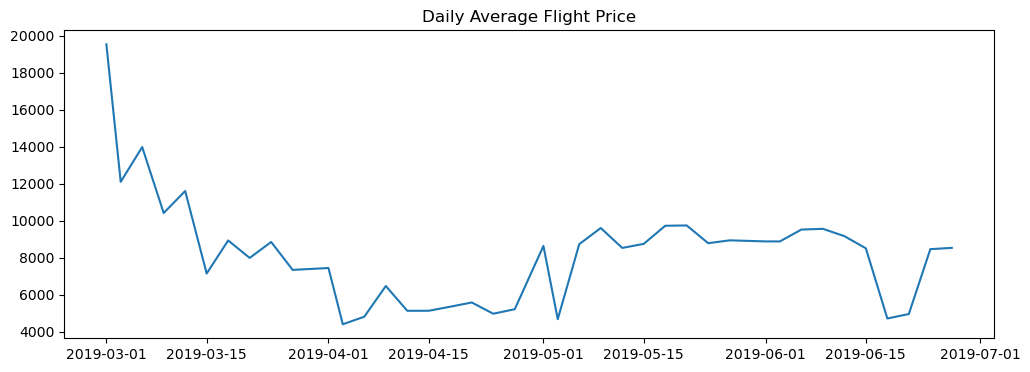

In [213]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(ts)
plt.title("Daily Average Flight Price")
plt.show()

In [215]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts.dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -2.5073116207305968
p-value: 0.1137054489938415


In [217]:
ts_log = np.log(ts)

In [219]:
ts_diff = ts_log.diff().dropna()


In [221]:
from statsmodels.tsa.stattools import adfuller

adf_diff = adfuller(ts_diff)
print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

ADF Statistic: -8.382915358108534
p-value: 2.4822041771749236e-13


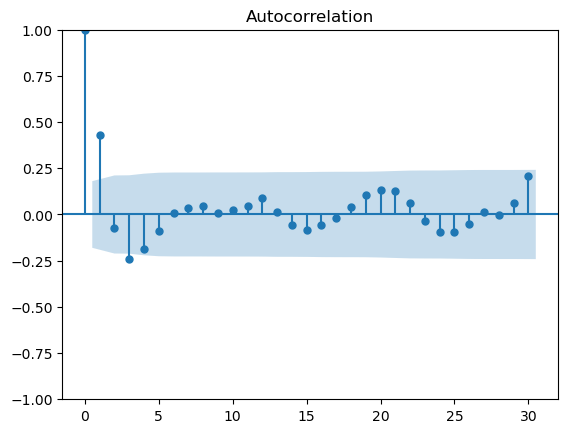

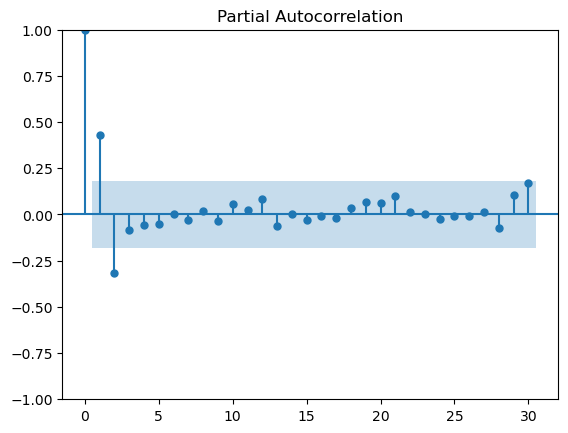

In [223]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(ts_diff, lags=30)
plot_pacf(ts_diff, lags=30)
plt.show()

In [224]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(ts_log, order=(1,1,1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                  119
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 124.787
Date:                Mon, 16 Feb 2026   AIC                           -243.573
Time:                        15:06:30   BIC                           -235.261
Sample:                    03-01-2019   HQIC                          -240.198
                         - 06-27-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1619      0.115      1.403      0.161      -0.064       0.388
ma.L1          0.3958      0.146      2.703      0.007       0.109       0.683
sigma2         0.0070      0.001     10.492      0.0

In [225]:
arima_forecast = arima_fit.forecast(steps=30)
arima_forecast = np.exp(arima_forecast)

# Model Comparison Report

* In this project, multiple time-series models were implemented to forecast daily average flight prices.

# The following models were evaluated: # 

* ARIMA(1,1,1)

* SARIMA(0,1,1)(1,1,1,7)

# Model comparison was performed using: # 

AIC (Akaike Information Criterion)

BIC (Bayesian Information Criterion)

Log-Likelihood

Residual diagnostics (Ljung-Box test)

Statistical significance of parameters

## Best Model for Production
### Recommended Model: SARIMA(0,1,1)(1,1,1,7)

🔹 Reason for Selection

Although ARIMA has lower AIC and BIC, SARIMA is preferred because:

1. Flight prices show weekly seasonality.

2. SARIMA explicitly models seasonal patterns.

3. Residual diagnostics indicate good fit.

4. More aligned with real-world business use case.

5. Provides better interpretability for weekly price cycles.